# Game sales analysis for an online store

We work with an online store that sells computer games worldwide. Historical data on game sales, user and expert ratings, genres, and platforms (e.g., Xbox or PlayStation) are available from public sources. We need to identify the patterns that determine a game's success. This will allow us to prioritize a potentially popular product and plan advertising campaigns.

The data is from 2016. According to the scenario, we are planning a campaign for 2017.

## Contents:
* [Step 1. General Information](#1-bullet)
* [Step 2. Data Preprocessing](#2-bullet)
* 2.1. [Replacing Column Headers](#2-1-bullet)
* 2.2. [Converting Data to Correct Types](#2-2-bullet)
* 2.3. [Processing Gaps](#2-3-bullet)
* 2.4. [Finding Duplicates](#2-4-bullet)
* 2.5. [Total Sales in All Regions](#2-5-bullet)
* [Step 3. Exploratory Data Analysis](#3-bullet)
* 3.1. [Number of Games Released Different Years](#3-1-bullet)
* 3.2. [Platforms](#3-2-bullet)
* 3.3. [Boxplot of Global Game Sales by Platform](#3-3-bullet)
* 3.4. [The Impact of User and Critic Reviews on Sales](#3-4-bullet)
* 3.5. [Game Distribution by Genre](#3-5-bullet)
* [Step 4. User Profile for Each Region](#4-bullet)
* 4.1. [Most Popular Genres (Top 5) in Each Region](#4-1-bullet)
* 4.2. [Most Popular Platforms (Top 5) in Each Region](#4-2-bullet)
* 4.3. [The Impact of ESRB Rating on Sales](#4-3-bullet)
* [Step 5. Hypothesis Testing](#5-bullet)
* 5.1. [Average User Ratings for Xbox One and PC Platforms Are the Same](#5-1-bullet)
* 5.2. [Average User Ratings for the Action and Sports Genres Are Different](#5-2-bullet)
* [Step 6. Overall Conclusion](#6-bullet)

## Step 1. General Information<a class="anchor" id="1-bullet"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


**Data Description**

* Name — Game name
* Platform — Platform
* Year_of_Release — Release Year
* Genre — Game Genre
* NA_sales — North American Sales (Millions of Copies Sold)
* EU_sales — European Sales (Millions of Copies Sold)
* JP_sales — Japanese Sales (Millions of Copies Sold)
* Other_sales — Other Sales (Millions of Copies Sold)
* Critic_Score — Critic Score (Maximum 100)
* User_Score — User Score (Maximum 10)
* Rating — Rating from the Entertainment Software Rating Board (ESRB). This association rates video games and assigns them an appropriate age rating.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


   
* The table has 11 columns and 16 715 rows.
* There are 2 missing values ​​in the ['Name'] column.
* There are 2 missing values ​​in the ['Year_of_Release'] column. These values ​​need to be converted from string to date.
* There are 2 missing values ​​in the ['Genre'] column.
* There are 8 578 missing values ​​in the ['Critic_Score'] column.
* There are 6 701 missing values ​​in the ['User_Score'] column. These values ​​need to be converted from string to number.
* There is 6 766 missing values ​​in the ['Rating'] column.
* Column names need to be replaced (converted to lowercase).


## Step 2. Data Preprocessing<a class="anchor" id="2-bullet"></a>

### 2.1. Replacing Column Headers<a class="anchor" id="2-1-bullet"></a>

In [3]:
df.columns = df.columns.str.lower()

In [4]:
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

### 2.2. Converting Data to Correct Types<a class="anchor" id="2-2-bullet"></a>

In [5]:
df['user_score'].value_counts()

tbd    2424
7.8     324
8       290
8.2     282
8.3     254
       ... 
0.6       2
0.5       2
0.9       2
9.7       1
0         1
Name: user_score, Length: 96, dtype: int64

    The abbreviation tbd (To Be Determined) appears quite frequently (2 424 times) in user ratings. This abbreviation stands for "to be determined later". There is currently no user rating for this. Let's replace the abbreviation tbd with NaN (a missing number in a cell, float data type) and convert the values ​​from string to number.

In [6]:
df['user_score'] = df['user_score'].replace('tbd', np.NaN)

In [7]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

   
     In the ['Year_of_Release'] column, we need to convert the values ​​from string to date.

In [8]:
df['year_of_release'] = pd.to_datetime(df['year_of_release'], format='%Y')
df['year'] = df['year_of_release'].dt.year

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             16713 non-null  object        
 1   platform         16715 non-null  object        
 2   year_of_release  16446 non-null  datetime64[ns]
 3   genre            16713 non-null  object        
 4   na_sales         16715 non-null  float64       
 5   eu_sales         16715 non-null  float64       
 6   jp_sales         16715 non-null  float64       
 7   other_sales      16715 non-null  float64       
 8   critic_score     8137 non-null   float64       
 9   user_score       7590 non-null   float64       
 10  rating           9949 non-null   object        
 11  year             16446 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(4)
memory usage: 1.5+ MB



* In the ['Year_of_Release'] column, values ​​have been converted from string to date.
* In the ['User_Score'] column, values ​​have been converted from string to number. The number of gaps has increased by 2 424 because the abbreviation "tbd" was replaced with NaN.


### 2.3. Processing Gaps<a class="anchor" id="2-3-bullet"></a>

   
There are two missing values ​​in the ['Name'] and ['Genre'] columns.
It's difficult to suggest a logical replacement for these missing values.
Let's look at the rows

In [10]:
df.query('name.isnull() & genre.isnull()')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,year
659,NaN,GEN,1993-01-01,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN,1993.0
14244,NaN,GEN,1993-01-01,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN,1993.0


    The gaps in two columns match. In these two rows, we only know the platform,
    year, and sales amount. Since these games were released back in 1993, the data is likely not
    relevant for planning 2017 advertising campaigns. We'll delete these rows, as they
    don't provide useful information for analysis.


In [11]:
df.dropna(subset = ['name'], inplace = True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             16713 non-null  object        
 1   platform         16713 non-null  object        
 2   year_of_release  16444 non-null  datetime64[ns]
 3   genre            16713 non-null  object        
 4   na_sales         16713 non-null  float64       
 5   eu_sales         16713 non-null  float64       
 6   jp_sales         16713 non-null  float64       
 7   other_sales      16713 non-null  float64       
 8   critic_score     8137 non-null   float64       
 9   user_score       7590 non-null   float64       
 10  rating           9949 non-null   object        
 11  year             16444 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(4)
memory usage: 1.7+ MB


* There are 269 missing values ​​in the ['year_of_release'] column, representing 1.6% of the total data.
    Filling with the mean or median is incorrect; logical substitutions cannot be made.

* There are a large number of missing values ​​in the ['critic_score'] and ['user_score'] columns. This means there are no critic or user ratings. Filling with the mean or median is incorrect; logical substitutions cannot be made. However, since there are so many missing values, there is a risk that NaN values ​​could lead to incorrect results when grouping data and making calculations. These missing values ​​will be filled with the value "-1" to avoid confusion with real data.

* There are 6 764 missing values ​​in the ['rating'] column. Missing values ​​mean that the international association has not determined a rating for the computer games and has not assigned them an appropriate age category or that this data was not entered. In any case, these gaps cannot logically be filled. You can replace the missing data with "no rating."

In [13]:
df['critic_score'] = df['critic_score'].fillna(-1)
df['user_score'] = df['user_score'].fillna(-1)
df['rating'] = df['rating'].fillna('no rating')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             16713 non-null  object        
 1   platform         16713 non-null  object        
 2   year_of_release  16444 non-null  datetime64[ns]
 3   genre            16713 non-null  object        
 4   na_sales         16713 non-null  float64       
 5   eu_sales         16713 non-null  float64       
 6   jp_sales         16713 non-null  float64       
 7   other_sales      16713 non-null  float64       
 8   critic_score     16713 non-null  float64       
 9   user_score       16713 non-null  float64       
 10  rating           16713 non-null  object        
 11  year             16444 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(4)
memory usage: 1.7+ MB


    Gaps remained in one column ['year'] - 1.6%

### 2.4. Finding Duplicates<a class="anchor" id="2-4-bullet"></a>

In [15]:
df.duplicated().sum()

0

In [16]:
df['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [17]:
df['genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

In [18]:
df['rating'].unique()

array(['E', 'no rating', 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'],
      dtype=object)

    No complete duplicates or hidden duplicates were found in the categorical values ​​in the dataset.

    Further, the ['rating'] column will combine the "E" and "K-A" categories, as they denote the same thing: "games for everyone."

### 2.5. Total Sales in All Regions<a class="anchor" id="2-5-bullet"></a>

In [19]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,year,total_sales
0,Wii Sports,Wii,2006-01-01,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,2006.0,82.54
1,Super Mario Bros.,NES,1985-01-01,Platform,29.08,3.58,6.81,0.77,-1.0,-1.0,no rating,1985.0,40.24
2,Mario Kart Wii,Wii,2008-01-01,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,2008.0,35.52
3,Wii Sports Resort,Wii,2009-01-01,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,2009.0,32.77
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,11.27,8.89,10.22,1.00,-1.0,-1.0,no rating,1996.0,31.38


Text(0.5, 1.0, 'Total Sales by Years')

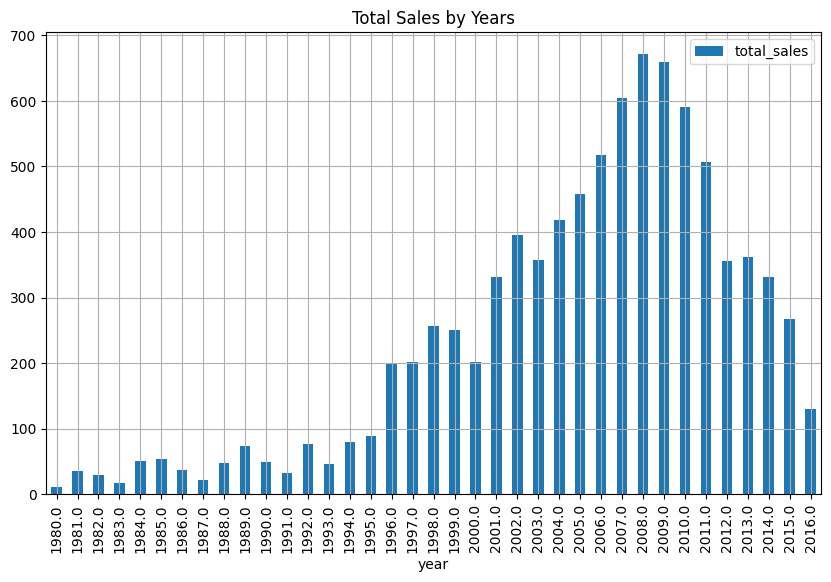

In [20]:
df.pivot_table(index='year', values='total_sales', aggfunc='sum').plot(kind='bar', grid=True, figsize=(10, 6))
plt.title('Total Sales by Years')

    Let's look at the distribution of sales by year. We see low sales of under $100 million between 1980 and 1995. Then, growth begins. Sales peaked in 2007 and 2008.
    Then, a decline begins. This may be due to the fact that mobile games are displacing console and computer games. 51% of all revenue in the gaming industry comes from mobile games. According to Newzoo analytics, the gap between mobile games and console, browser, and computer games will only widen with each passing year.

## Step 3. Exploratory Data Analysis<a class="anchor" id="3-bullet"></a>

### 3.1. Number of Games Released Different Years <a class="anchor" id="3-1-bullet"></a> 

Text(0.5, 1.0, 'Number of Games Released in Different Years')

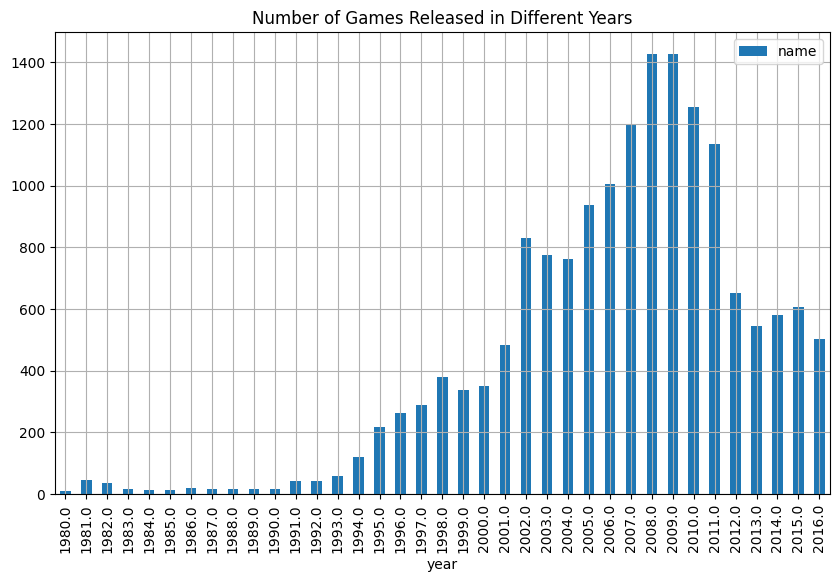

In [21]:
df.pivot_table(index='year', values='name', aggfunc='count').plot(kind='bar', grid=True, figsize=(10, 6))
plt.title('Number of Games Released in Different Years')

In [22]:
df.groupby('year')['name'].agg(['count']).sort_values('count',ascending=False).head(15)

,count
year,
2008.0,1427
2009.0,1426
2010.0,1255
2007.0,1197
2011.0,1136
2006.0,1006
2005.0,939
2002.0,829
2003.0,775


    Let's look at the number of games released in different years.
    The lowest number of games was released between 1980 and 1994.
    Then, growth begins. A sharp spike occurs in 2002. Game releases peak between 2008 and 2009.
    Then, a decline begins. As mentioned above, this decline is due to the development of mobile games.

### 3.2. Platforms<a class="anchor" id="3-2-bullet"></a>

Text(0.5, 1.0, 'Number of Games Released on Different Platforms')

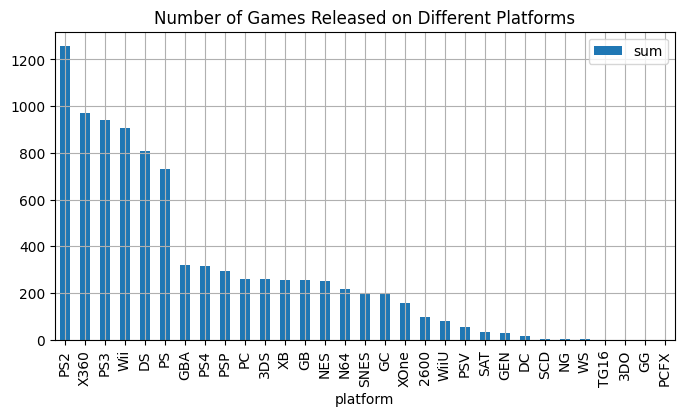

In [23]:
df.groupby('platform')['total_sales'].agg(['sum']).sort_values('sum',ascending=False).plot(kind='bar', grid=True, figsize=(8, 4))
plt.title('Number of Games Released on Different Platforms')

In [24]:
df.groupby('platform')['total_sales'].agg(['sum']).sort_values('sum',ascending=False).head(6)

,sum
platform,
PS2,1255.77
X360,971.42
PS3,939.65
Wii,907.51
DS,806.12
PS,730.86


Let's analyze the 6 best-selling platforms: PS2, X360, PS3, Wii, DS, PS.

In [25]:
platform_list = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']

<AxesSubplot:xlabel='year'>

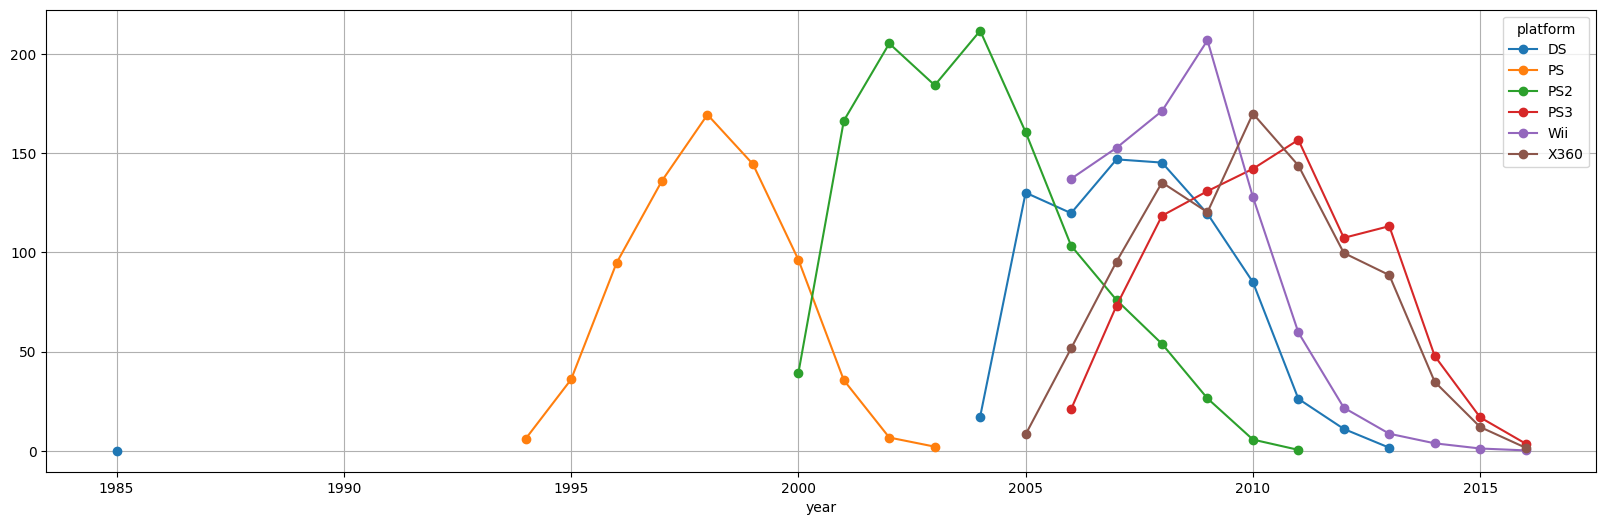

In [26]:
df.query('platform == @platform_list').pivot_table(index='year', columns='platform', values='total_sales', aggfunc='sum').plot(style='o-', grid=True, figsize=(20, 6))


In [27]:
df.query('platform == @platform_list').pivot_table(index='year', columns='platform', values='total_sales', aggfunc='sum')

platform,DS,PS,PS2,PS3,Wii,X360
year,,,,,,
1985.0,0.02,NaN,NaN,NaN,NaN,NaN
1994.0,NaN,6.03,NaN,NaN,NaN,NaN
1995.0,NaN,35.96,NaN,NaN,NaN,NaN
1996.0,NaN,94.70,NaN,NaN,NaN,NaN
1997.0,NaN,136.17,NaN,NaN,NaN,NaN
1998.0,NaN,169.49,NaN,NaN,NaN,NaN
1999.0,NaN,144.53,NaN,NaN,NaN,NaN
2000.0,NaN,96.37,39.17,NaN,NaN,NaN
2001.0,NaN,35.59,166.43,NaN,NaN,NaN




Let's analyze the 6 best-selling platforms.
* 1994-2003, ***PS*** platform, sales period of 10 years.
* 2000-2011, ***PS2*** platform, sales period of 12 years.
* 2004-2013, ***DS*** platform, sales period of 10 years.
* 2005-2016, ***X360*** platform, sales period of 12 years.
* 2006-2016, ***PS3*** platform, sales period of 11 years.
* 2006-2016, ***Wii*** platform, sales period of 11 years.

Platforms disappear within 10-12 years. The three platforms that were still selling in 2016 generated a meager profit of $3.60 - $0.18 million. This means these platforms will disappear soon. We need to find platforms that were released 5-6 years ago and that had the highest profits in recent years.

Text(0.5, 1.0, 'Sales by Platform Established After 2010')

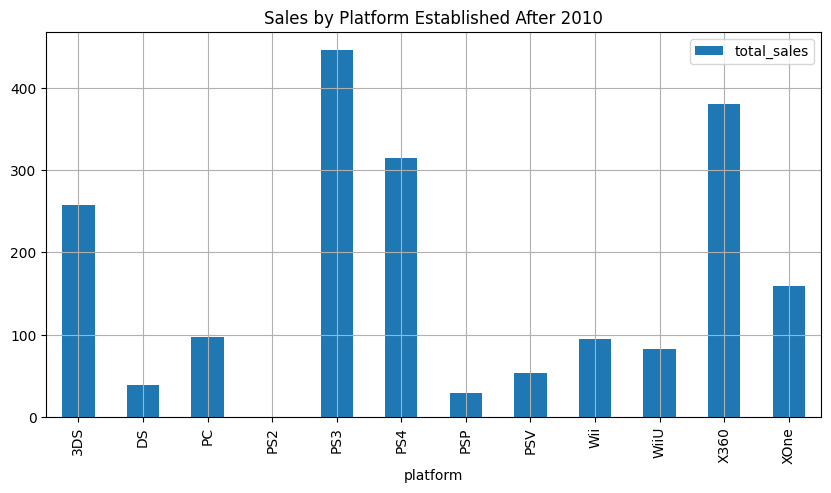

In [28]:
df.query('year > 2010').pivot_table(index='platform', values='total_sales', aggfunc='sum').plot(kind='bar', grid=True, figsize=(10, 5))
plt.title('Sales by Platform Established After 2010')

In [29]:
df.query('year > 2010').pivot_table(index='platform', columns='year', values='total_sales', aggfunc='sum')

year,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0
platform,,,,,,
3DS,63.20,51.36,56.57,43.76,27.78,15.14
DS,26.18,11.01,1.54,NaN,NaN,NaN
PC,35.03,23.22,12.38,13.28,8.52,5.25
PS2,0.45,NaN,NaN,NaN,NaN,NaN
PS3,156.78,107.36,113.25,47.76,16.82,3.60
PS4,NaN,NaN,25.99,100.00,118.90,69.25
PSP,17.82,7.69,3.14,0.24,0.12,NaN
PSV,4.63,16.19,10.59,11.90,6.25,4.25
Wii,59.65,21.71,8.59,3.75,1.14,0.18


From 2011 to 2016, the top five sales were:
PS3, X360, PS4, 3DS, XOne.

It's necessary to analyze sales by year to determine the trend.
Which platforms are seeing growth in sales, and which are seeing declines.

<AxesSubplot:xlabel='year'>

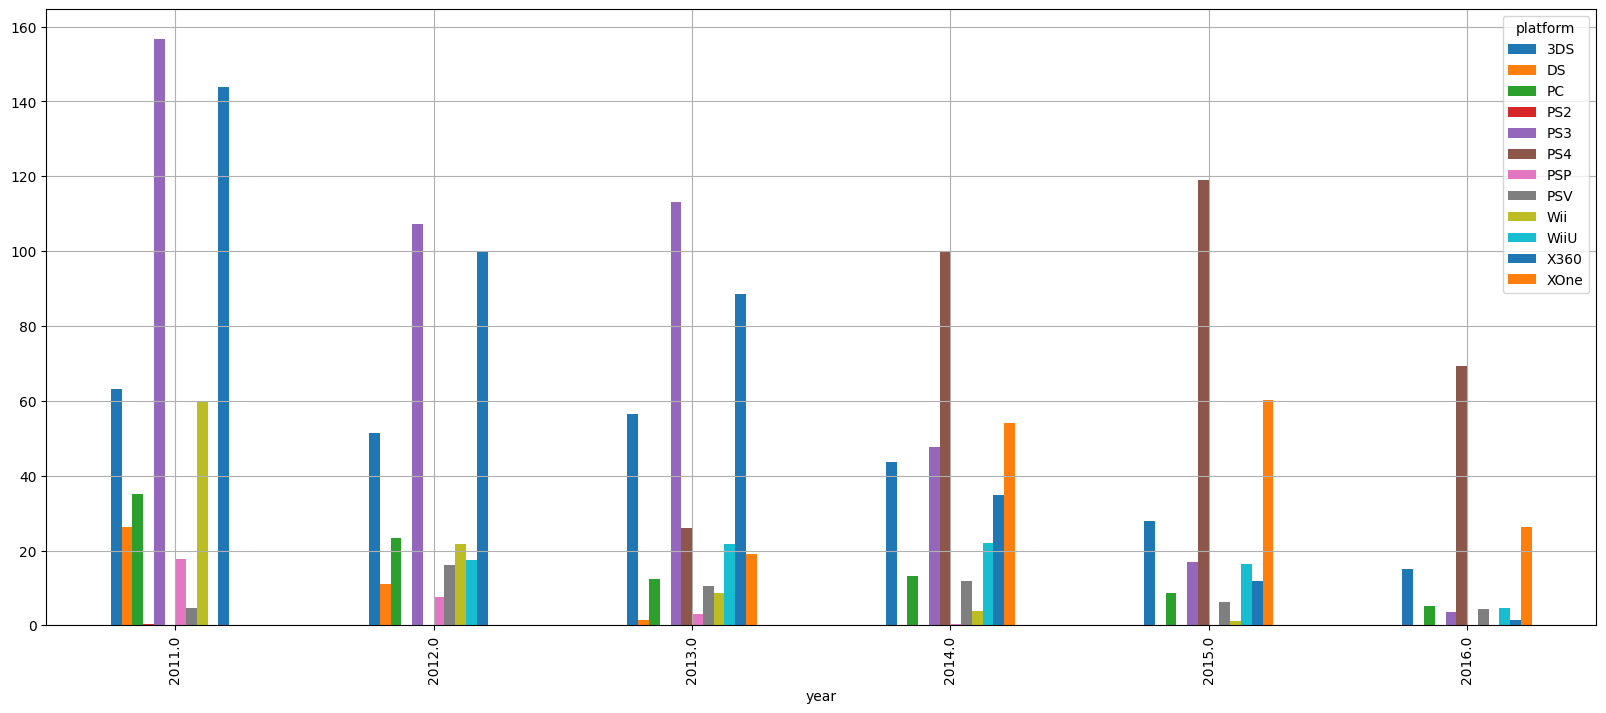

In [30]:
df.query('year > 2010').pivot_table(index='year', columns='platform', values='total_sales', aggfunc='sum').plot(kind='bar', grid=True, figsize=(20, 8))


In [31]:
platform_list_new = ['3DS', 'PS4', 'WiiU', 'XOne']

In [32]:
df.query('platform == @platform_list_new & year > 2010').pivot_table(index='year', columns='platform', values='total_sales', aggfunc='sum')

platform,3DS,PS4,WiiU,XOne
year,,,,
2011.0,63.20,NaN,NaN,NaN
2012.0,51.36,NaN,17.56,NaN
2013.0,56.57,25.99,21.65,18.96
2014.0,43.76,100.00,22.03,54.07
2015.0,27.78,118.90,16.35,60.14
2016.0,15.14,69.25,4.60,26.15


Platforms to focus on next year:
* ***PS4*** - released in 2011, has been on sale for 7 years, and has had the highest profitability over the past 3 years (2014-2016)
* ***XOne*** - released in 2013, has been on sale for 5 years, and has been the second-largest profit-maker over the past 3 years (2014-2016)
* ***3DS*** - released in 2011, has been on sale for 7 years, and has been the third-largest profit-maker over the past 3 years (2014-2016)

***WiiU***, although a relatively new platform (on sale for 6 years), has seen its profitability decline year after year. The other platforms have been on sale for 10 years or more.

Let's take the current period from 2011 to 2016. Two new platforms were released that year, and a third was released later in 2013. For three years, these platforms competed and battled with the current leaders, reaching the top positions in 2014. Since 2010, a decline in the number of games released and overall sales has begun, leaving only a few platforms capable of competing in the market.

### 3.3 Boxplot of Global Game Sales by Platform<a class="anchor" id="3-3-bullet"></a>

Let's plot a boxplot of global sales for each game, then break it down by platform. Let's compare the results.

(-0.1, 1.1)

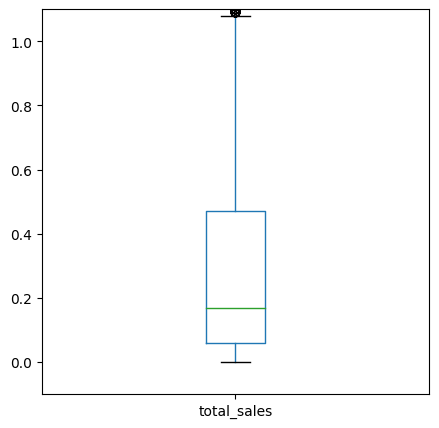

In [33]:
df['total_sales'].plot.box(figsize=(5,5))
plt.ylim(-0.1, 1.10)

In [34]:
df['total_sales'].describe()

count    16713.000000
mean         0.533315
std          1.548282
min          0.000000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.540000
Name: total_sales, dtype: float64

    Game sales reach up to $1.1 million. The median is $0.17 million.

    
***Boxplot for the most popular platforms at the end of 2016***

(-0.25, 1.8)

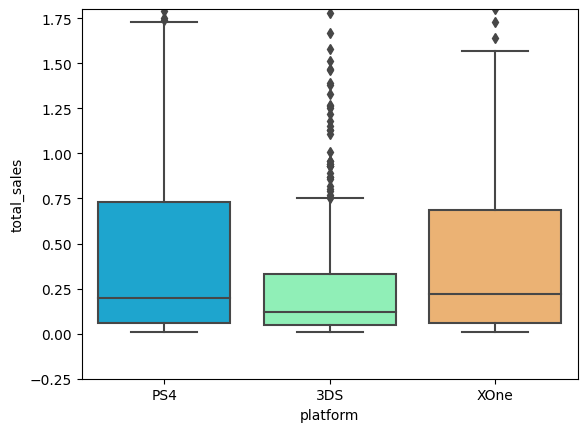

In [35]:
column_list1 = ['PS4', 'XOne', '3DS']
df_1 = df.query('platform == @column_list1')
import seaborn as sns
sns.boxplot(x="platform", y="total_sales", data=df_1, palette='rainbow')
plt.ylim(-0.25, 1.8)


In [36]:
df.query('platform == @column_list1').pivot_table(index='platform', values='total_sales', aggfunc=('median', 'mean'))

,mean,median
platform,,
3DS,0.498077,0.12
PS4,0.801378,0.20
XOne,0.645020,0.22


- ***PS4*** - Sales reach up to 1.75 million dollars. The interquartile range is greater than that of the 3DS and XOne platforms. We also see that the PS4 platform's dataset is more skewed to the right. This channel attracts those who spend more on games than the median. Therefore, the average value for this platform is the highest – 0.8 million dollars, the median is $0.2 million.

- ***XOne*** - Sales reach up to 1.58 million dollars. The interquartile range is smaller than that of the PS4 platform. The dataset is skewed to the right, but less than that of the PS4 platform. The average value for this platform is lower than that of the PS4 – 0.65 million dollars, and the median is higher – $0.22 million.

- ***3DS*** is in third place. Sales reach up to 0.75 million dollars. The average value is 0.49 million dollars, the median is $0.12 million.

The ***PS4*** and ***XOne*** platform results exceed the global sales figures for each game. The ***3DS*** platform results are lower than the global sales figures for each game.

### 3.4. The Impact of User and Critic Reviews on Sales<a class="anchor" id="3-4-bullet"></a>


**The Impact of Critic Reviews on Sales Within One Popular PS4 Platform**

<AxesSubplot:xlabel='critic_score', ylabel='total_sales'>

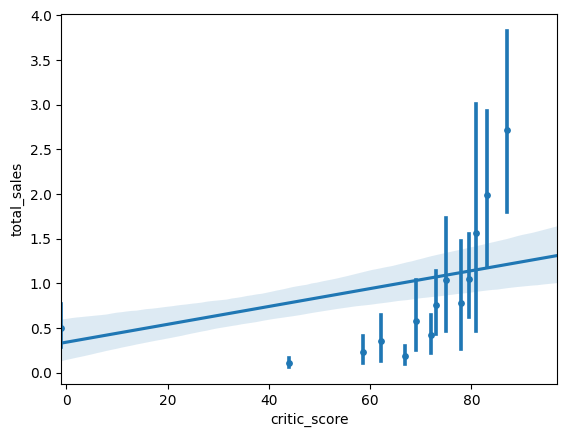

In [37]:
df_PS4 = df.query('platform == "PS4"')
sns.regplot(x='critic_score', y='total_sales',data=df_PS4, x_bins=20, scatter_kws={'s':15})

In [38]:
df_PS4['critic_score'].corr(df_PS4['total_sales'])

0.22652606614612347

The graph shows a relationship: as the first variable (critic reviews) increases,
the second variable (sales) increases. That is, the higher the critic reviews, the higher the sales.

The Pearson coefficient is 0.23. The closer the Pearson coefficient is to 1, the stronger the relationship.

**The Impact of User Reviews on Sales Within One Popular PS4 Platform**

<AxesSubplot:xlabel='user_score', ylabel='total_sales'>

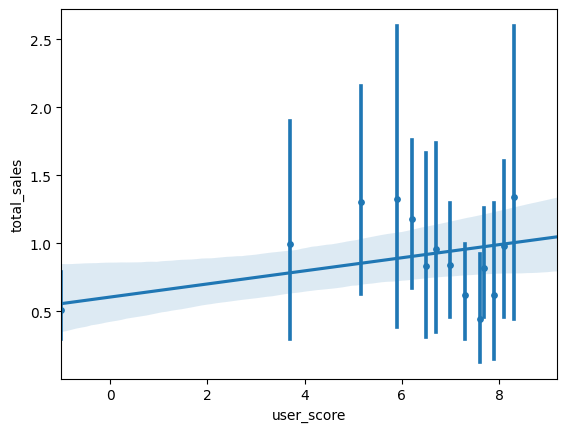

In [39]:
sns.regplot(x='user_score', y='total_sales',data=df_PS4, x_bins=20, scatter_kws={'s':15})

In [40]:
df_PS4['user_score'].corr(df_PS4['total_sales'])

0.1159614931286009

The graph shows a relationship: as the first variable (user reviews) increases, the second variable (sales) increases. That is, the higher the user reviews, the higher the sales.

The Pearson coefficient is 0.12. The closer the Pearson coefficient is to 1, the stronger the relationship.

User ratings have less of an impact on sales than critic ratings.

**The impact of critic reviews on sales across all platforms for the current period**

<AxesSubplot:xlabel='critic_score', ylabel='total_sales'>

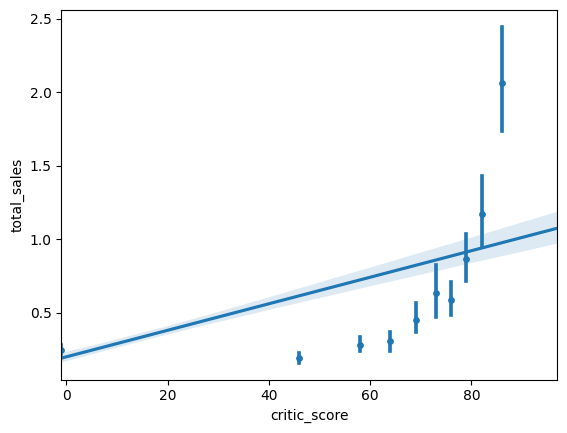

In [41]:
data_2011 = df.query('year > 2010')
sns.regplot(x='critic_score', y='total_sales',data=data_2011, x_bins=20, scatter_kws={'s':15})

In [42]:
data_2011['critic_score'].corr(data_2011['total_sales'])

0.2736884811636506

When we take data from all platforms, the correlation between critic reviews and sales increases.

The Pearson coefficient increased from 0.23 to 0.27.

**The impact of user reviews on sales across all platforms for the current period**

<AxesSubplot:xlabel='user_score', ylabel='total_sales'>

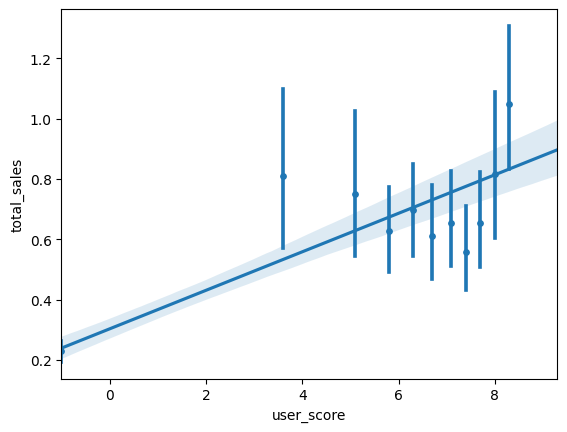

In [43]:
data_2011 = df.query('year > 2010')
sns.regplot(x='user_score', y='total_sales',data=data_2011, x_bins=20, scatter_kws={'s':15})

In [44]:
data_2011['user_score'].corr(data_2011['total_sales'])

0.20781653635258424

When we consider data from all platforms, the correlation between user reviews and sales increases.

The Pearson coefficient increased from 0.12 to 0.21.

User ratings have a lesser impact on sales than critic ratings.
However, in the overall dataset, the difference between these two metrics narrows.

### 3.5. Game Distribution by Genre<a class="anchor" id="3-5-bullet"></a>

Text(0.5, 1.0, 'Number of Games Released by Genre')

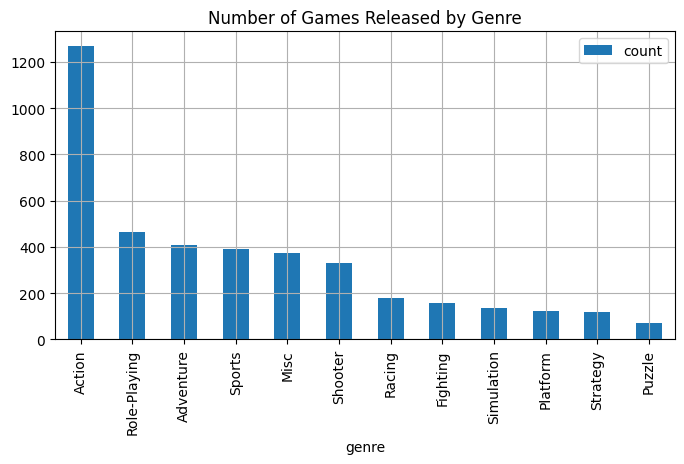

In [45]:
data_2011.groupby('genre')['name'].agg(['count']).sort_values('count',ascending=False).plot(kind='bar', grid=True, figsize=(8, 4))
plt.title('Number of Games Released by Genre')

The Action genre is the most popular genre.
The number of games in this genre far exceeds all other genres.

The second most popular genres are:
Role-Playing, Adventure, Sports, Misc, and Shooter.

The third most popular genres are:
Racing, Fighting, Simulation, Platform, Strategy, and Puzzle.

Text(0.5, 1.0, 'Sales by Genre')

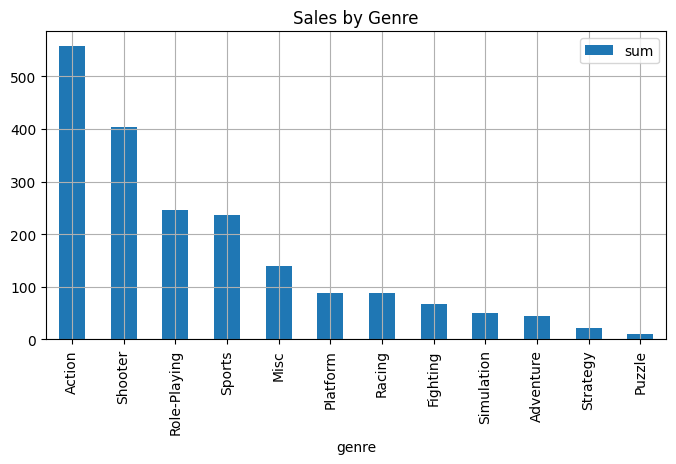

In [46]:
data_2011.groupby('genre')['total_sales'].agg(['sum']).sort_values('sum',ascending=False).plot(kind='bar', grid=True, figsize=(8, 4))
plt.title('Sales by Genre')

High-selling genres:
Action, Shooter, Role-Playing, Sports.

Low-selling genres:
Misc, Platform, Racing, Fighting, Simulation, Adventure, Strategy, Puzzle

Thus, the Action genre produces the most games and generates the most revenue.

Let's see how much a game of each genre costs on average.

<AxesSubplot:xlabel='genre'>

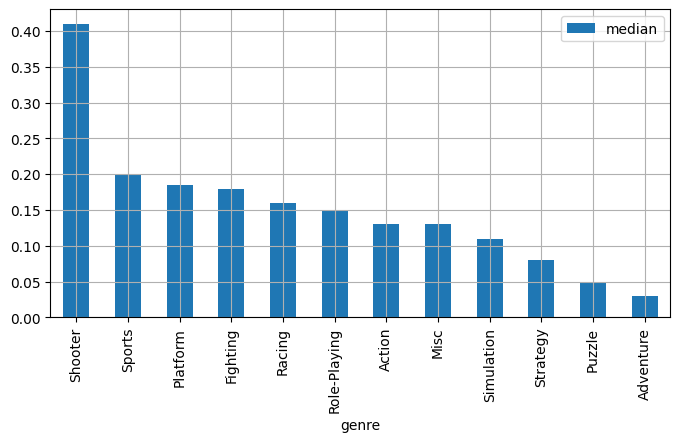

In [47]:
data_2011.groupby('genre')['total_sales'].agg(['median']).sort_values('median',ascending=False).plot(kind='bar', grid=True, figsize=(8, 4))

    The most expensive games were shooters, at $0.4 million, twice as much as the closest competitor, sports games, at $0.2 million.

    The top-selling action game, the Action genre, has a price tag of $0.13 million.

### Step 4. User Profile for Each Region<a class="anchor" id="4-bullet"></a>

### 4.1. Most Popular Genres (Top 5) in Each Region<a class="anchor" id="4-1-bullet"></a>

Text(0.5, 1.0, 'Japan Sales')

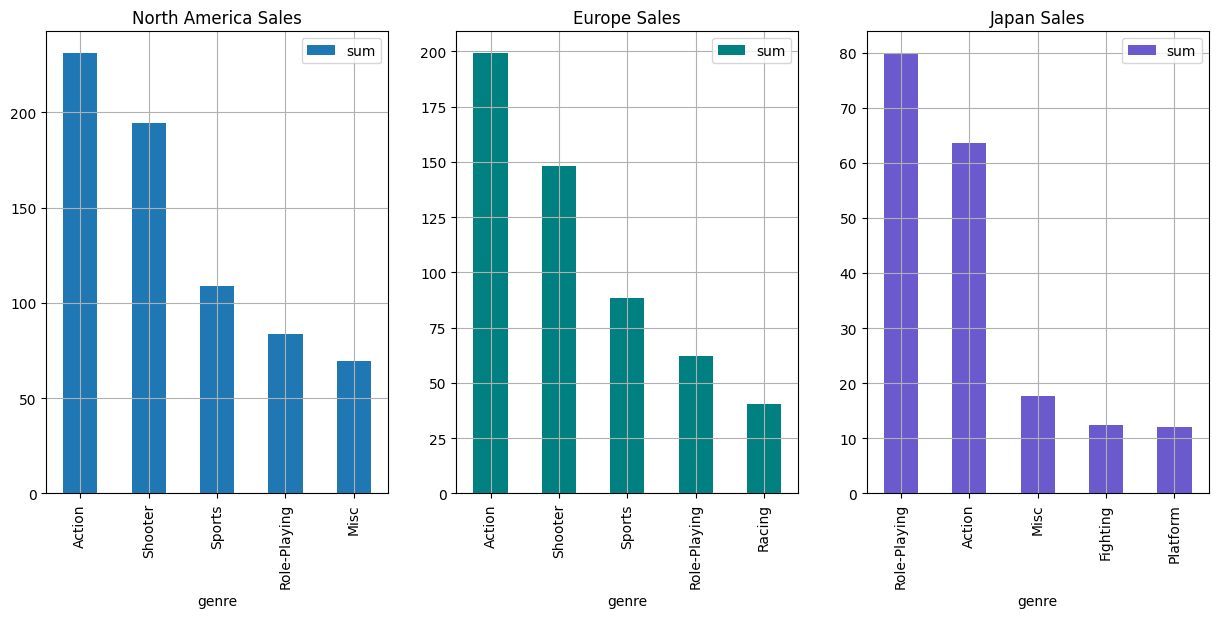

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15,6))
data_2011.groupby('genre')['na_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[0], )
data_2011.groupby('genre')['eu_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[1], color='teal')
data_2011.groupby('genre')['jp_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[2], color='slateblue')
axes[0].set_title('North America Sales')
axes[1].set_title('Europe Sales')
axes[2].set_title('Japan Sales')

    The four most popular genres in North America are identical to those in Europe.
    In descending order: Action, Shooter, Sports, and Role-Playing.
    The only difference is in fifth place: in North America, it's Misc (mixed genre), while in Europe, it's Racing.

    Preferences in Japan are quite different.
    Role-Playing is first, Action is second, and the other three genres lag far behind the leaders.

### 4.2. Most Popular Platforms (Top 5) in Each Region<a class="anchor" id="4-2-bullet"></a>

Text(0.5, 1.0, 'Japan Sales')

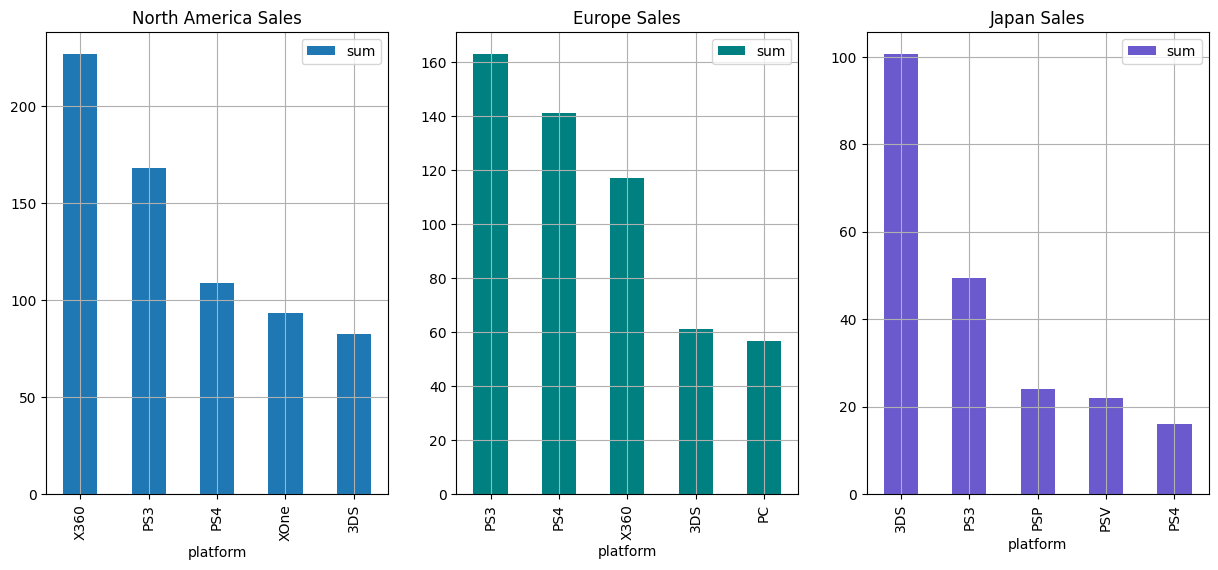

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15,6))
data_2011.groupby('platform')['na_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[0], )
data_2011.groupby('platform')['eu_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[1], color='teal')
data_2011.groupby('platform')['jp_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[2], color='slateblue')
axes[0].set_title('North America Sales')
axes[1].set_title('Europe Sales')
axes[2].set_title('Japan Sales')

    In North America, the X360 is the top platform (released in 2005, on sale for 12 years).
    In Europe, the top platform is the PS3 (released in 2006, on sale for 11 years).
    In Japan, the clear leader is the 3DS, which ranks 4th and 5th in North America and Europe, respectively (released in 2011, on sale for 7 years).

### 4.3. The Impact of ESRB Rating on Sales<a class="anchor" id="4-3-bullet"></a>

**ESRB Rating Explanation**

- "E" (Everyone) — For Everyone
- "E10+" (Everyone 10 and Older) — For Everyone Over 10
- "T" (Teen) — For Teens 13-19
- "M" (Mature) — 17+
- "K-A" (Kids to Adults) — For Kids and Adults, i.e., this is the equivalent of "E"
- "AO" (Adults Only 18+) — For Adults Only
- "EC" (early childhood) — the game is intended specifically for younger children (ages 3 and up)
- "RP" (Rating Pending) — Rating Pending

We'll combine the "E" and "K-A" categories.

In [50]:
data_2011['rating'].replace('K-A', 'E').value_counts()

no rating    1708
M             622
E             618
T             616
E10+          456
RP              1
EC              1
Name: rating, dtype: int64

Text(0.5, 1.0, 'Japan Sales')

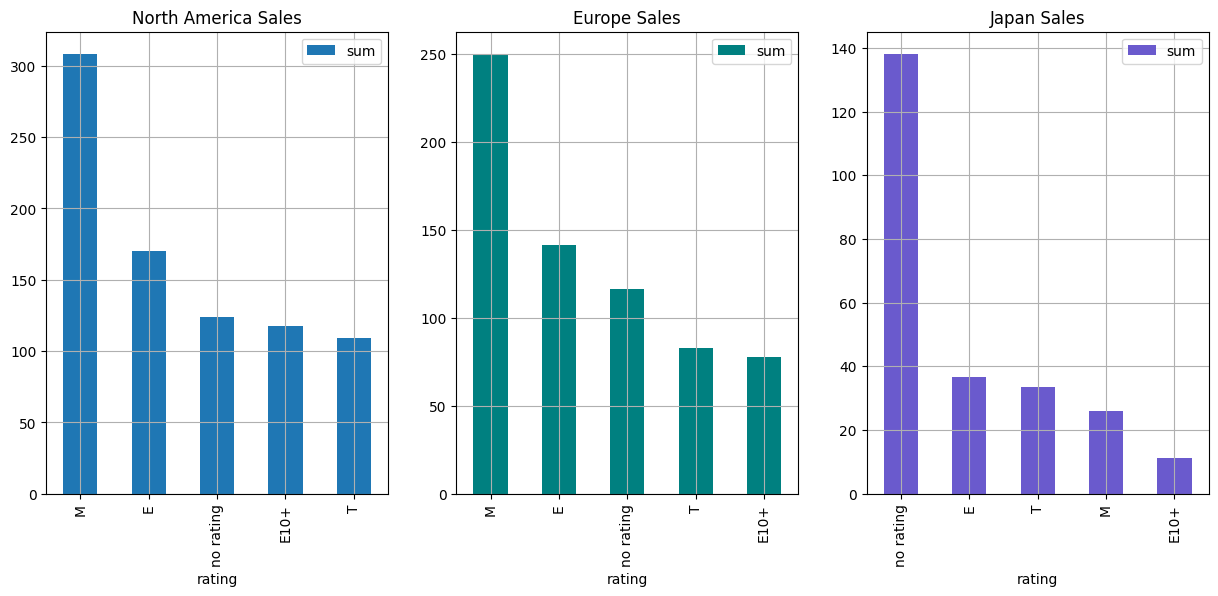

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15,6))
data_2011.groupby('rating')['na_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[0], )
data_2011.groupby('rating')['eu_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[1], color='teal')
data_2011.groupby('rating')['jp_sales'].agg(['sum']).sort_values('sum',ascending=False).head().plot(kind='bar', grid=True, ax=axes[2], color='slateblue')
axes[0].set_title('North America Sales')
axes[1].set_title('Europe Sales')
axes[2].set_title('Japan Sales')

    The ratings charts for North America and Europe are very similar. The first three positions are identical.
    In both regions, games rated "M" (Mature) — 17+ — are preferred.
    Games rated "E" — for everyone — are in second place.
    Games rated "Unspecified" are in third place.
    Fourth and fifth place are games rated "For Everyone 10+" and "Teens 13-19."
    In both charts, the difference between these two categories is insignificant.

    In Japan, the most popular games are those rated "Unspecified."
    This could be because the ESRB is a non-governmental organization whose primary focus is the adoption and determination of ratings for computer video games and other entertainment software in the United States and Canada.
    This organization may not be familiar with Japanese products.

### Step 5. Hypothesis Testing<a class="anchor" id="5-bullet"></a>

### 5.1. Average User Ratings for Xbox One and PC Platforms Are the Same<a class="anchor" id="5-1-bullet"></a>

*H0 (null hypothesis)* - the average user ratings for the ***Xbox One*** and ***PC*** platforms are the same.

*H1 (alternative hypothesis)* - the average user rating for the ***Xbox One*** platform differs from the average user rating for the ***PC*** platform.

alpha threshold = 0.05

In [52]:
from scipy import stats as st

In [53]:
data_XOne = data_2011[(data_2011['platform'] == 'XOne')]
data_PC = data_2011[(data_2011['platform'] == 'PC')]

In [54]:
alpha = 0.05
results = st.ttest_ind(data_XOne['total_sales'], data_PC['total_sales'], equal_var = True)

print('p-value:', results.pvalue)

if (results.pvalue < alpha):
    print ('we reject the hypothesis')
else:
    print ('failed to reject the hypothesis')

p-value: 3.102478340371612e-10
we reject the hypothesis


    The hypothesis was not confirmed, and we have grounds to reject it.

    Therefore, the average user rating for the Xbox One platform differs from the average user rating for the PC platform.


### 5.2. Average User Ratings for the Action and Sports Genres Are Different <a class="anchor" id="5-2-bullet"></a>

*H0 (null hypothesis)* - the average user ratings for the ***Action*** and ***Sports*** genres are the same.

*H1 (alternative hypothesis)* - the average user rating for the ***Action*** genre differs from the average user rating for the ***Sports*** genre.

In [55]:
data_аction = data_2011[(data_2011['genre'] == 'Action')]
data_sports = data_2011[(data_2011['genre'] == 'Sports')]

In [56]:
alpha = 0.05
results = st.ttest_ind(data_аction['user_score'], data_sports['user_score'], equal_var = True)

print('p-value:', results.pvalue)

if (results.pvalue < alpha):
    print ('we reject the hypothesis')
else:
    print ('failed to reject the hypothesis')

p-value: 0.5428125413900603
failed to reject the hypothesis


    There are no grounds to reject the null hypothesis.
    The average user ratings for the Action and Sports genres are identical.

### Step 6. Overall Conclusion <a class="anchor" id="6-bullet"></a>

Since 2010, the number of games released annually and overall sales have been declining. This may be due to mobile games displacing console and PC games. Mobile games account for 51% of all revenue in the gaming industry. According to Newzoo analytics, the gap between mobile games and console, browser, and PC games will only widen with each passing year.

_____________________________________________________________________________________________

On average, platforms disappear 10-12 years after their release.
Platforms to focus on next year:

- PS4 - released in 2011, has been on sale for 7 years, has had the highest revenue over the past 3 years (2014-2016) - $288.15 million
- Xbox One - released in 2013, has been on sale for 5 years, has had the second-highest revenue over the past 3 years (2014-2016) - 140.36 million dollars
- 3DS - released in 2011, has been on sale for 7 years, has had the third-highest revenue over the past 3 years (2014-2016) - 86.68 million dollars
___________________________________________________________________________________________________

Critic reviews have a greater impact on sales than user reviews.
___________________________________________________________________________________________________

- High-selling genres: Action, Shooter, Role-Playing, Sports.
- The Action genre is the most popular genre. The number of games in this genre far exceeds all others.
- Shooter games turned out to be the most expensive at 0.4 million dollars, twice as much as the next-best seller, Sports (0.2 million dollars). The top-selling Action game was $0.13 million.
***************************************************************************************************
If we look at the user profile by region, preferences in North America are very close to those in Europe. The data for preferences in Japan differs sharply.

The top three genres in North America and Europe are the same:
Action, Shooter, Sports.

In Japan, Role-Playing is first, Action is second, with the other three genres lagging far behind.

Platform preferences varied by region:
* In North America, the X360 (released in 2005, on sale for 12 years) is the most popular platform.
* In Europe, the PS3 (released in 2006, on sale for 11 years) is the most popular platform.
* In Japan, the 3DS is the clear leader, ranking fourth and fifth in North America and Europe, respectively. (Released in 2011, on sale for 7 years.)

The top three ESRB-rated game categories in North America and Europe are the same: first place is "M" (ages 17+), second place is "E" (for everyone), and third place is games with an unspecified rating.

In Japan, the most popular games have an unspecified rating. This could be because the ESRB is a non-governmental organization that sets ratings for computer video games and other entertainment software in the United States and Canada. This organization may not be familiar with products from Japan. 